<a href="https://colab.research.google.com/github/ebi19912/AI/blob/main/vgg19_autoencoder_chest_xray_auc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ConvNeXtLarge
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Conv2D, BatchNormalization
from tensorflow.keras.layers import AvgPool2D, MaxPool2D, ReLU, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.metrics import AUC

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, confusion_matrix,
    matthews_corrcoef, average_precision_score, precision_recall_curve, roc_curve, roc_auc_score
)

from tensorflow.compat.v1.logging import INFO, set_verbosity
from tensorflow.python.framework.ops import disable_eager_execution
from matplotlib import rcParams
from keras.preprocessing import image
import os
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout   # اگر می‌خوای Dropout هم اضافه کنیم

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ConvNeXtLarge
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Conv2D, BatchNormalization
from tensorflow.keras.layers import AvgPool2D, MaxPool2D, ReLU, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.metrics import AUC

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, confusion_matrix,
    matthews_corrcoef, average_precision_score, precision_recall_curve, roc_curve, roc_auc_score
)

from tensorflow.compat.v1.logging import INFO, set_verbosity
from tensorflow.python.framework.ops import disable_eager_execution
from matplotlib import rcParams
from keras.preprocessing import image

2025-11-11 04:58:16.603482: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762837096.810488      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762837096.865455      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
img_dir = "/kaggle/input/nih-chest-x-ray-14-224x224-resized/images-224/images-224"


In [ ]:
dataframe = pd.read_csv("/kaggle/input/nih-chest-x-ray-14-224x224-resized/Data_Entry_2017.csv")

columns = ["Image"]
for i in dataframe["Finding Labels"].values:
    for j in i.split("|"):
        if j not in columns:
            columns.append(j)
labels = columns.copy()
labels.remove("Image")

all_data = pd.DataFrame(columns=columns)
image_indices = dataframe["Image Index"].values
finding_labels = dataframe["Finding Labels"].values

data_list = []
for i in range(len(image_indices)):
    col = {c: 0 for c in columns}
    col["Image"] = image_indices[i]
    for j in finding_labels[i].split("|"):
        if j in col:
            col[j] = 1
    data_list.append(col)

all_data = pd.DataFrame(data_list)


train_df, test_val_df = train_test_split(all_data, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(test_val_df, test_size=0.5, random_state=42)

print(f"train num: {len(train_df)}")
print(f"validation num: {len(val_df)}")
print(f"test num: {len(test_df)}")

trainset = train_df.reset_index(drop=True)
valset = val_df.reset_index(drop=True)
testset = test_df.reset_index(drop=True)

train num: 78484
validation num: 16818
test num: 16818


In [ ]:
def isOverlap(s1, s2):
    total = set(s1).intersection(set(s2))
    return [len(total), total]

def overlapcheck(trainset, valset, testset):
    patid_train = []
    patid_val = []
    patid_test = []
    for name in trainset['Image'].values:
        patid_train.append(int(name.split("_")[0]))

    for name in valset['Image'].values:
        patid_val.append(int(name.split("_")[0]))

    for name in testset['Image'].values:
        patid_test.append(int(name.split("_")[0]))
    trte = isOverlap(patid_train, patid_test)
    teva = isOverlap(patid_test, patid_val)
    trva = isOverlap(patid_train, patid_val)
    print("Patient Overlap - Train and Test: ", trte[0])
    print("Patient Overlap - Test and Validation: ", teva[0])
    print("Patient Overlap - Train and Validation: ", trva[0])
    return trte, teva, trva

#Checking for overlaps between trainset, testset and validation set
trte, teva, trva = overlapcheck(trainset, valset, testset)

#Removing overlapping patients
for i in trva[1]:
    for name in trainset['Image'].values:
        if(int(name.split("_")[0]) == i):
            trainset.drop(trainset.loc[trainset['Image'] == name].index, inplace=True)

#Checking for overlaps after removing common patients
trte, teva, trva = overlapcheck(trainset, valset, testset)

Patient Overlap - Train and Test:  6677
Patient Overlap - Test and Validation:  4116
Patient Overlap - Train and Validation:  6636
Patient Overlap - Train and Test:  2802
Patient Overlap - Test and Validation:  4116
Patient Overlap - Train and Validation:  0


In [ ]:
def label_counts(df):
    label_counts = df[labels].sum().sort_values(ascending=False)
    return label_counts

print("Training Data Label Counts:")
print(label_counts(trainset))
print("\nValidation Data Label Counts:")
print(label_counts(valset))
print("\nTest Data Label Counts:")
print(label_counts(testset))

Training Data Label Counts:
No Finding            20076
Infiltration           4037
Atelectasis            2368
Effusion               1972
Nodule                 1599
Mass                   1314
Pleural_Thickening      789
Cardiomegaly            710
Consolidation           602
Pneumothorax            540
Fibrosis                530
Emphysema               377
Edema                   258
Pneumonia               231
Hernia                   67
dtype: int64

Validation Data Label Counts:
No Finding            9109
Infiltration          2979
Effusion              1972
Atelectasis           1658
Nodule                1011
Pneumothorax           827
Mass                   826
Consolidation          707
Pleural_Thickening     493
Cardiomegaly           410
Emphysema              365
Edema                  332
Fibrosis               239
Pneumonia              200
Hernia                  39
dtype: int64

Test Data Label Counts:
No Finding            9101
Infiltration          2897
Effusion   

Maximum Pixel Value:  0.8901961
Minimum Pixel Value:  0.0
Image dimension: 224 x 224 
Mean - Pixel Value:  0.5003819
Std Deviation Pixel Value:  0.22861302


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Pixel Values', ylabel='Count'>

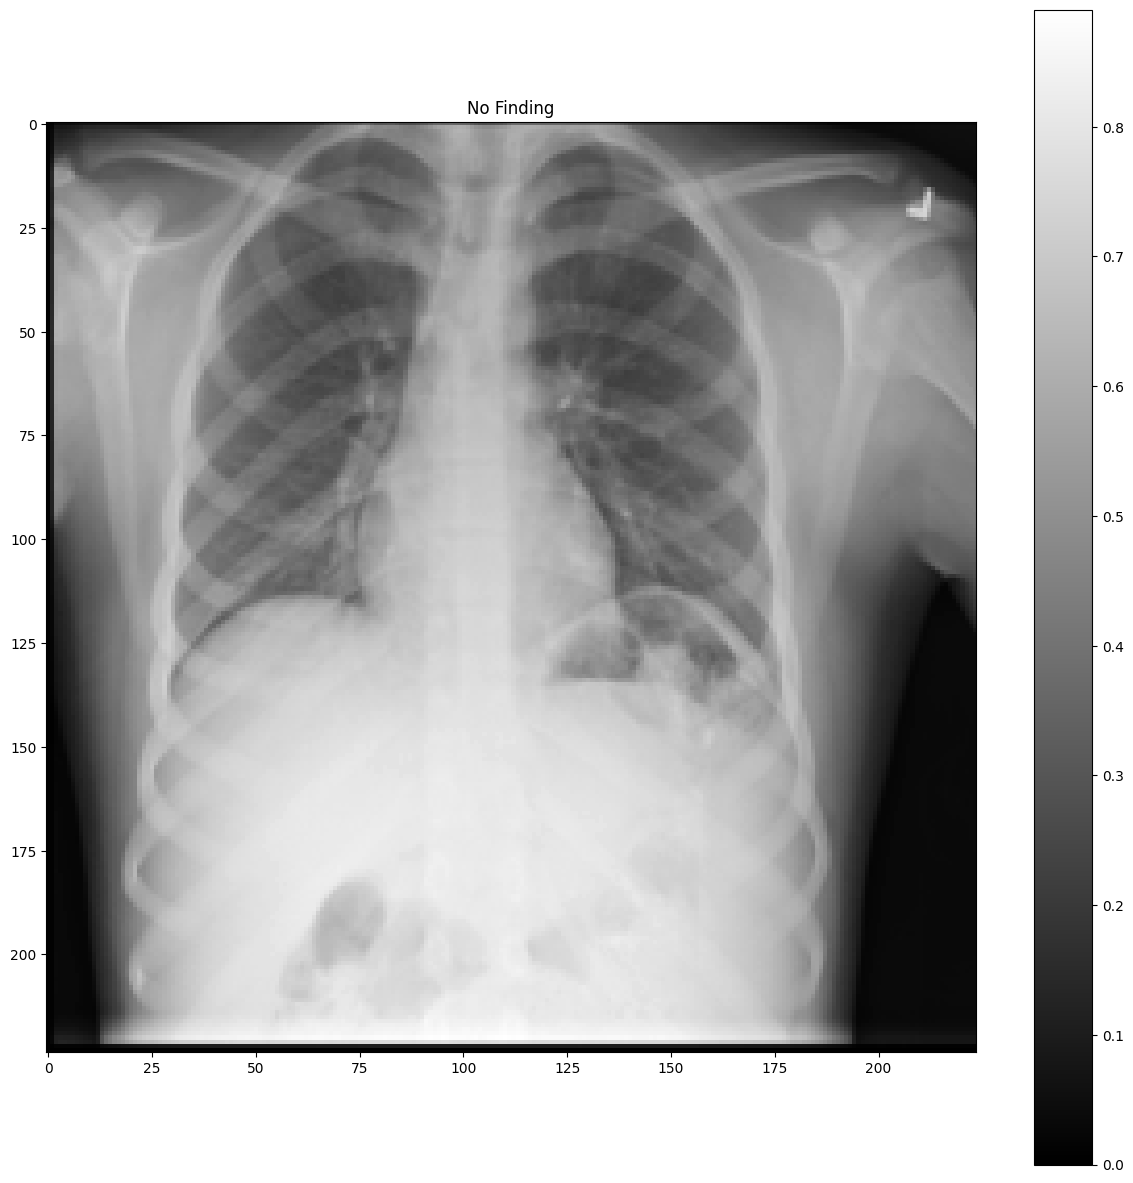

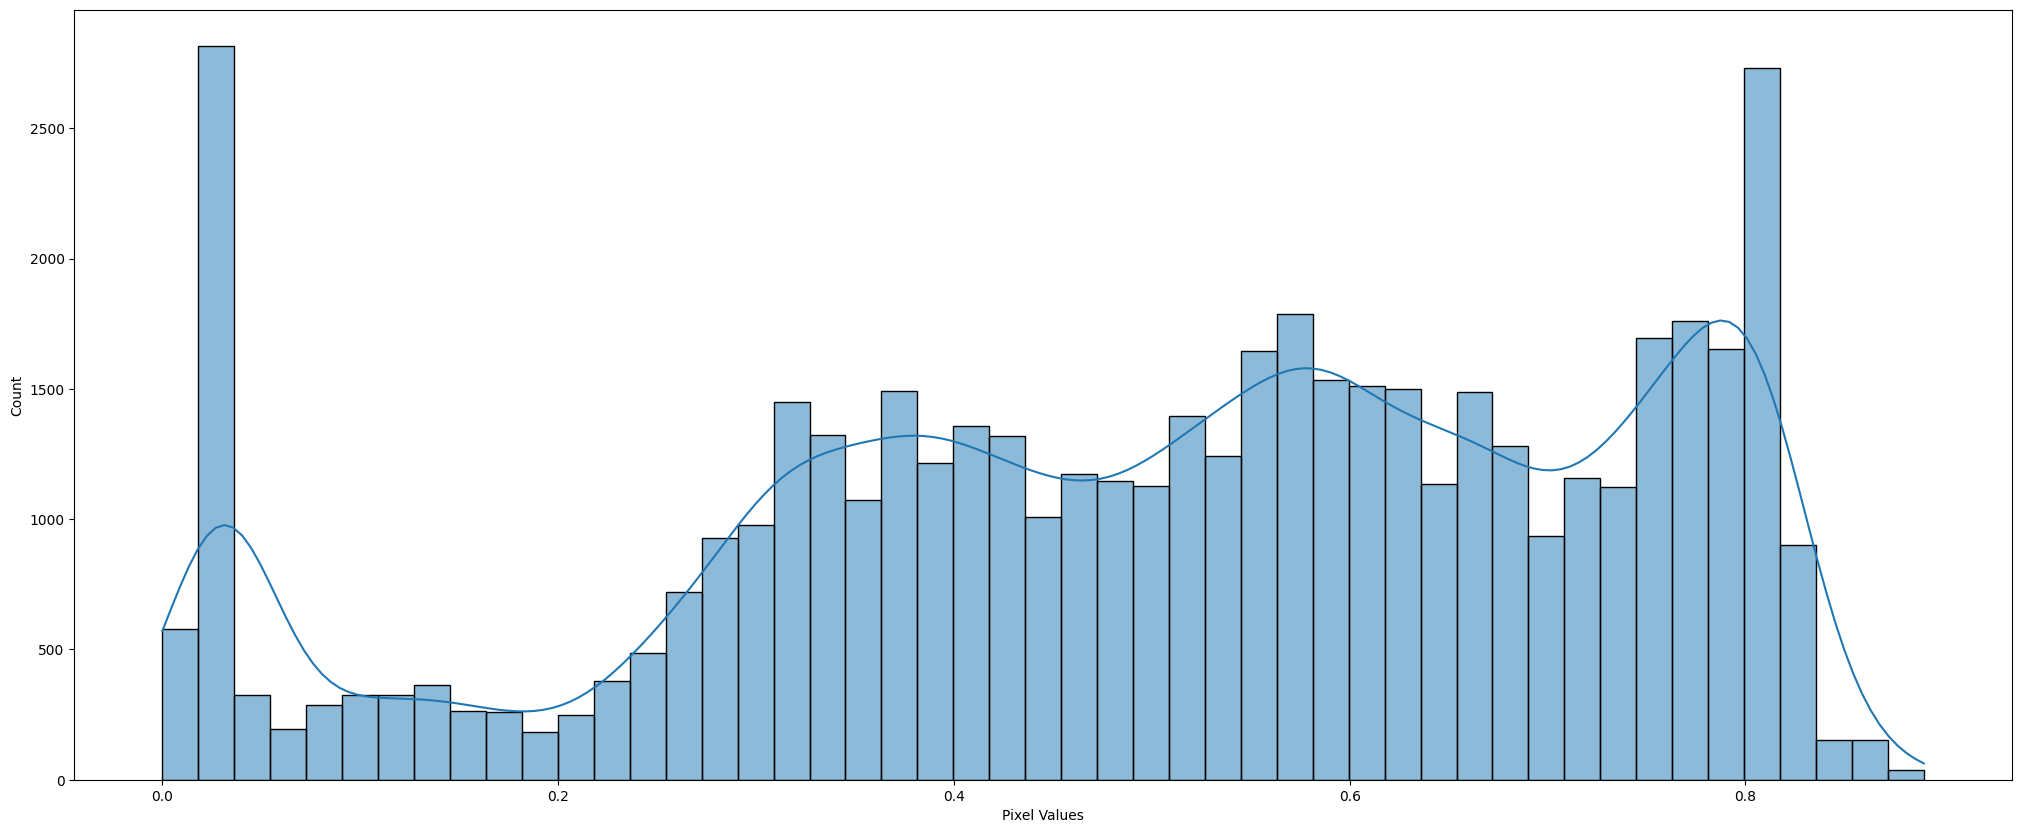

In [ ]:
num = np.random.randint(trainset.shape[0])
sample = plt.imread(os.path.join(img_dir,trainset.iloc[[num]]["Image"].values[0]))
plt.figure(figsize=(15, 15))
plt.title(dataframe[dataframe["Image Index"] == trainset.iloc[[num]]["Image"].values[0]].values[0][1])
plt.imshow(sample, cmap = 'gray')
plt.colorbar()
trainset.iloc[[num]]

print("Maximum Pixel Value: ", sample.max())
print("Minimum Pixel Value: ", sample.min())
print(f"Image dimension: {sample.shape[0]} x {sample.shape[1]} ")

fig, ax = plt.subplots(figsize=(25, 10))
plt.xlabel("Pixel Values")
print("Mean - Pixel Value: ", sample.mean())
print("Std Deviation Pixel Value: ", sample.std())
sns.histplot(sample.ravel(), ax = ax, kde = True)

Found 30895 validated image filenames.
Found 30895 validated image filenames.
Found 16818 validated image filenames.
Found 16818 validated image filenames.


I0000 00:00:1762838478.696915      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


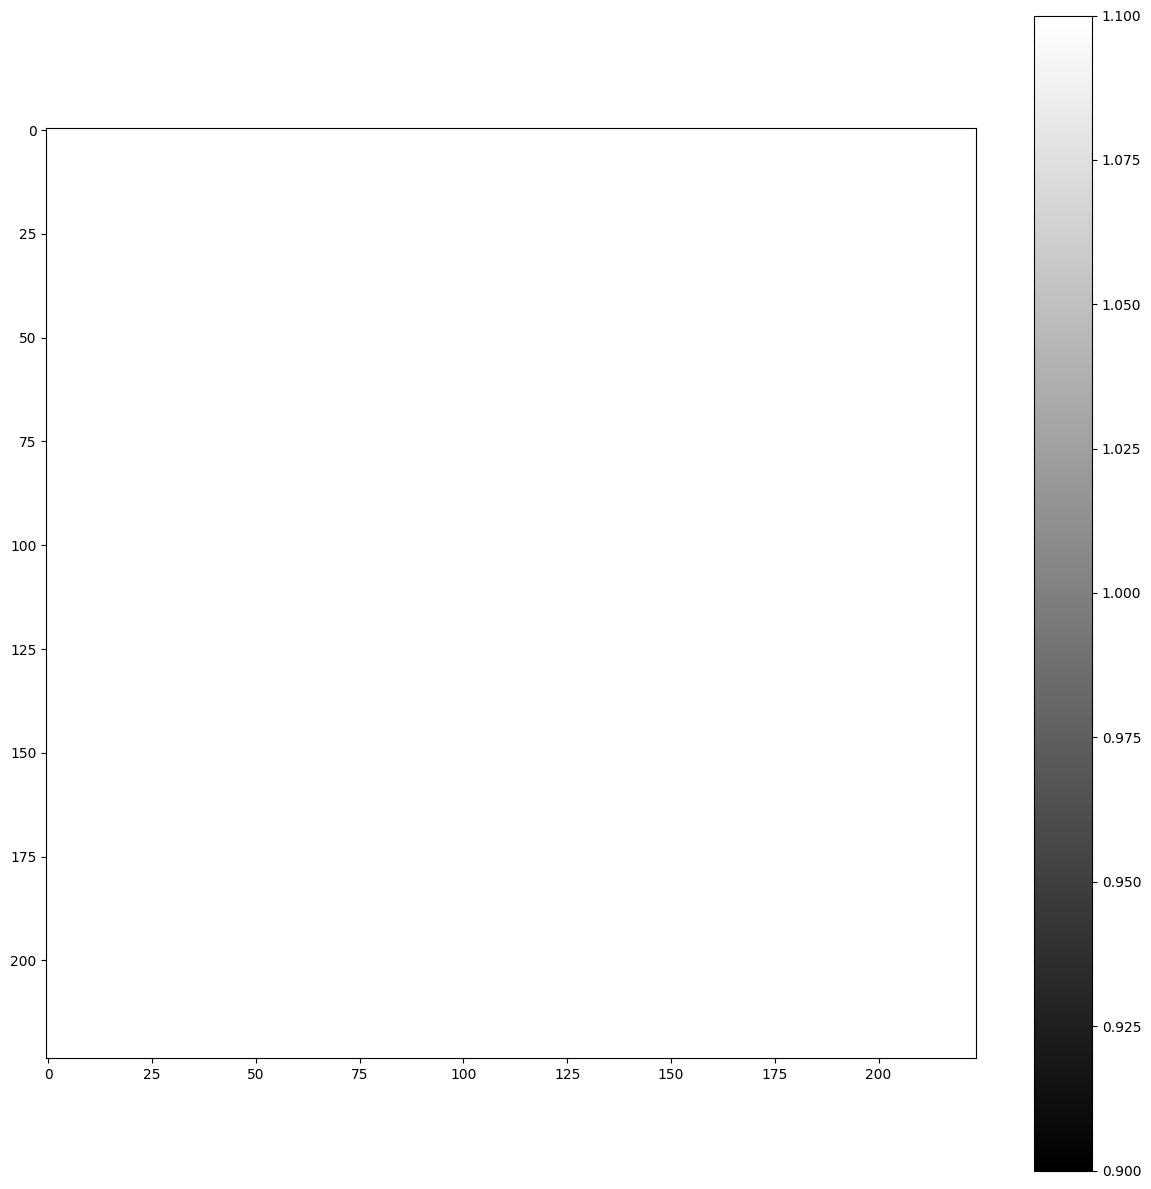

In [ ]:
def adjust_contrast_and_saturation(image):
  # Generate a random contrast factor between 0.4 and 0.9
  contrast_factor = tf.random.uniform([], 0.4, 0.9)
  image = tf.image.adjust_contrast(image, contrast_factor)

  # Generate a random saturation factor between 0.4 and 0.9
  #saturation_factor = tf.random.uniform([], 0.4, 0.9)
  #image = tf.image.adjust_saturation(image, saturation_factor)

  return image

traingen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    brightness_range=[0.3, 1.2],
    zoom_range=0.2,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=False,
    preprocessing_function=adjust_contrast_and_saturation
)


sample_generator = ImageDataGenerator().flow_from_dataframe(
    dataframe=trainset,
    directory=img_dir,
    x_col="Image",
    y_col=labels,
    class_mode="raw",
    batch_size=10000, # یک بچ بزرگ برای محاسبه آمار دقیق‌تر
    shuffle=True,
    target_size=(224, 224)
)
sample_images, _ = next(sample_generator)
traingen.fit(sample_images)


val_test_gen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
)

val_test_gen.mean = traingen.mean
val_test_gen.std = traingen.std


bach = 32
traingenerator = traingen.flow_from_dataframe(
        dataframe=trainset,
        directory=img_dir,
        x_col="Image",
        y_col= labels,
        class_mode="raw",
        batch_size= bach,
        shuffle=True,
        target_size=(224,224)
)

valgenerator = val_test_gen.flow_from_dataframe(
    dataframe=valset,
    directory=img_dir,
    x_col="Image",
    y_col=labels,
    class_mode="raw",
    batch_size=bach,
    shuffle=False,
    target_size=(224, 224)
)

testgenerator = val_test_gen.flow_from_dataframe(
    dataframe=testset,
    directory=img_dir,
    x_col="Image",
    y_col=labels,
    class_mode="raw",
    batch_size=bach,
    shuffle=False,
    target_size=(224, 224)
)


num = np.random.randint(len(traingenerator))
item, value = traingenerator.__getitem__(num)
plt.figure(figsize=(15, 15))
plt.imshow(item[0], cmap='gray')
plt.colorbar()
plt.show()

<Figure size 2000x1500 with 0 Axes>

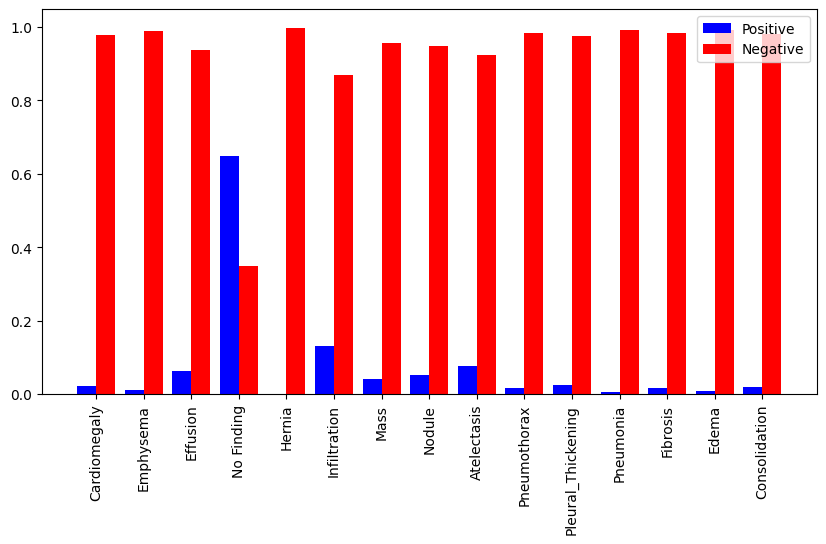

<Figure size 2000x1500 with 0 Axes>

In [ ]:
# Calculate positive and negative frequencies for each label
positive_freqs = trainset[labels].sum().values / trainset.shape[0]  # Assuming labels are 1 for positive, 0 for negative
negative_freqs = 1 - positive_freqs

data = {
    'Class': labels,
    'Positive': positive_freqs, #* negative_freqs, #Removed
    'Negative': negative_freqs #* positive_freqs #Removed
}

X_axis = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(X_axis-0.2, data['Positive'], width=0.4, color='b', label = "Positive")
ax.bar(X_axis+0.2, data['Negative'], width=0.4, color='r', label = 'Negative')
plt.xticks(X_axis, labels, rotation = 90)
plt.legend()
plt.figure(figsize=(20,15))

In [ ]:
# Assuming you have your labels and save directory defined

save_dir = '/kaggle/working/'
os.makedirs(save_dir, exist_ok=True)

# Define a function to create the model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, concatenate, Flatten, Lambda
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import VGG19
import tensorflow as tf
import os
def create_model():
    reg = regularizers.l1_l2(l1=1e-6, l2=1e-4)

    # Load pretrained encoder
    encoder = load_model('/kaggle/input/autoencoder-model/encoder_model.keras', compile=False)
    for layer in encoder.layers:
        layer.trainable = False

    # Input
    input_tensor = Input(shape=(224, 224, 3), name='input_rgb')

    # Encoder branch (grayscale + resize to match encoder input)
    encoder_input = Lambda(lambda x: tf.image.resize(tf.reduce_mean(x, axis=-1, keepdims=True), (128, 128)),
                           name='rgb_to_gray_resize')(input_tensor)
    encoder_output = encoder(encoder_input)
    encoder_flat = Flatten(name='encoder_flat')(encoder_output)

    # VGG19 branch
    vgg_base = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    for layer in vgg_base.layers:
        layer.trainable = False

    for layer in vgg_base.layers[-8:]:
        layer.trainable = True

    vgg_feat = vgg_base(input_tensor)
    vgg_gap = GlobalAveragePooling2D(name='vgg_gap')(vgg_feat)
    vgg_dense = Dense(128, activation='relu', name='vgg_dense')(vgg_gap)

    # Merge both features
    merged = concatenate([encoder_flat, vgg_dense], name='concat_features')

    # Dense classifier with L1/L2
    x = Dense(
        512,
        activation='relu',
        name='dense1',
        kernel_regularizer=reg
    )(merged)
    x = Dropout(0.5, name='dropout1')(x)

    x = Dense(
        256,
        activation='relu',
        name='dense2',
        kernel_regularizer=reg
    )(x)
    x = Dropout(0.5, name='dropout2')(x)

    output = Dense(
        len(labels),
        activation='sigmoid',
        name='output',
        kernel_regularizer=reg
    )(x)
    model = Model(inputs=input_tensor, outputs=output)
    return model



model = create_model()
model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_rgb (InputLayer)    │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rgb_to_gray_resize        │ (None, 128, 128, 1)    │              0 │ input_rgb[0][0]        │
│ (Lambda)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg19 (Functional)        │ (None, 7, 7, 512)      │     20,024,384 │ input_rgb[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ encoder (Functional)      │ (None, 16, 16, 128)    │         92,672 │ rgb_to_gray_resize[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg_gap                   │ (None, 512)            │              0 │ vgg19[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ encoder_flat (Flatten)    │ (None, 32768)          │              0 │ encoder[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg_dense (Dense)         │ (None, 128)            │         65,664 │ vgg_gap[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concat_features           │ (None, 32896)          │              0 │ encoder_flat[0][0],    │
│ (Concatenate)             │                        │                │ vgg_dense[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense1 (Dense)            │ (None, 512)            │     16,843,264 │ concat_features[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout1 (Dropout)        │ (None, 512)            │              0 │ dense1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense2 (Dense)            │ (None, 256)            │        131,328 │ dropout1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout2 (Dropout)        │ (None, 256)            │              0 │ dense2[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output (Dense)            │ (None, 15)             │          3,855 │ dropout2[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 37,161,167 (141.76 MB)

 Trainable params: 31,202,959 (119.03 MB)

 Non-trainable params: 5,958,208 (22.73 MB)

In [ ]:
def weighted_cross_entropy(y_true, y_pred):
    # Calculate positive and negative weights based on class frequencies in your dataset.
    positive_weights = tf.constant(positive_freqs, dtype=tf.float32)  # Example positive weights
    negative_weights = tf.constant(negative_freqs, dtype=tf.float32)  # Example negative weights

    # Calculate the weighted loss
    loss = -(y_true * tf.math.log(y_pred + 1e-7) * positive_weights + (1 - y_true) * tf.math.log(1 - y_pred + 1e-7) * negative_weights)

    return tf.reduce_mean(loss)

In [ ]:
# Function to train the model and save it
def train_and_save_model(model_name):
    auc_macro = tf.keras.metrics.AUC(
    multi_label=True,
    num_labels=len(labels),
    name='auc_macro')

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=3e-5), loss=weighted_cross_entropy, metrics=[auc_macro])

    # Define callbacks
    checkpoint = ModelCheckpoint(f'{model_name}.keras',
                                 monitor='val_auc_macro',
                                 verbose=1,
                                 save_best_only=True,
                                 mode='max')
    early_stopping = EarlyStopping(
        monitor='val_auc_macro',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    # Train the model
    history = model.fit(
        traingenerator,
        epochs=100,
        validation_data=valgenerator,
        callbacks=[checkpoint, early_stopping]
    )

    return history

# Train the model and save it
history = train_and_save_model('VGG19_Autoencoder_chest_xray_ensemble')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1762838492.004252     102 service.cc:148] XLA service 0x7f99d000c590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762838492.005338     102 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762838493.124743     102 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/966 ━━━━━━━━━━━━━━━━━━━━ 6:11:20 23s/step - auc_macro: 0.4562 - loss: 1.2898

I0000 00:00:1762838507.376056     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


966/966 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - auc_macro: 0.5113 - loss: 0.3623
Epoch 1: val_auc_macro improved from -inf to 0.52787, saving model to VGG19_Autoencoder_chest_xray_ensemble.keras
966/966 ━━━━━━━━━━━━━━━━━━━━ 1037s 1s/step - auc_macro: 0.5113 - loss: 0.3622 - val_auc_macro: 0.5279 - val_loss: 0.1963
Epoch 2/100
966/966 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - auc_macro: 0.5252 - loss: 0.1908
Epoch 2: val_auc_macro improved from 0.52787 to 0.55345, saving model to VGG19_Autoencoder_chest_xray_ensemble.keras
966/966 ━━━━━━━━━━━━━━━━━━━━ 727s 752ms/step - auc_macro: 0.5253 - loss: 0.1908 - val_auc_macro: 0.5534 - val_loss: 0.1406
Epoch 3/100
966/966 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - auc_macro: 0.5388 - loss: 0.1382
Epoch 3: val_auc_macro improved from 0.55345 to 0.58024, saving model to VGG19_Autoencoder_chest_xray_ensemble.keras
966/966 ━━━━━━━━━━━━━━━━━━━━ 710s 735ms/step - auc_macro: 0.5388 - loss: 0.1381 - val_auc_macro: 0.5802 - val_loss: 0.1099
Epoch 4/100
966/966 ━━━━━━━

In [ ]:
predicted_vals = model.predict(testgenerator)

526/526 ━━━━━━━━━━━━━━━━━━━━ 191s 361ms/step


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             matthews_corrcoef, average_precision_score, confusion_matrix,
                             roc_curve, roc_auc_score, precision_recall_curve)

weighted_precision_list = []
weighted_recall_list = []
weighted_f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

all_gt = np.array(testgenerator.labels)
all_pred_probs = predicted_vals

for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred_probs = all_pred_probs[:, i]

        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred, average="weighted")
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        pred = (pred_probs > best_thresh).astype(int)

        weighted_precision = precision_score(gt, pred, average="weighted")
        weighted_recall = recall_score(gt, pred, average="weighted")
        weighted_f1 = f1_score(gt, pred, average="weighted")
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        weighted_precision_list.append(weighted_precision)
        weighted_recall_list.append(weighted_recall)
        weighted_f1_list.append(weighted_f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass

metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Precision': weighted_precision_list,
    'Recall': weighted_recall_list,
    'F1-Score': weighted_f1_list,
    'Accuracy': accuracy_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

print("\nOverall  Metrics:")
print(f"Mean Precision: {np.mean(weighted_precision_list):.4f}")
print(f"Mean Recall: {np.mean(weighted_recall_list):.4f}")
print(f"Mean F1-Score: {np.mean(weighted_f1_list):.4f}")
print(f"Mean Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Mean MCC: {np.mean(mcc_list):.4f}")
print(f"Mean AUC-PR: {np.mean(auc_pr_list):.4f}")


Best threshold for Cardiomegaly: 0.0143
Confusion Matrix for Cardiomegaly (Threshold: 0.0143):
[[16398     0]
 [  420     0]]
Specificity for Cardiomegaly: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Best threshold for Emphysema: 0.0259
Confusion Matrix for Emphysema (Threshold: 0.0259):
[[16474     0]
 [  344     0]]
Specificity for Emphysema: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Best threshold for Effusion: 0.031700000000000006
Confusion Matrix for Effusion (Threshold: 0.031700000000000006):
[[14435   379]
 [ 1844   160]]
Specificity for Effusion: 0.9744160928851087
Best threshold for No Finding: 0.0001
Confusion Matrix for No Finding (Threshold: 0.0001):
[[   0 7717]
 [   0 9101]]
Specificity for No Finding: 0.0


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Best threshold for Edema: 0.0127
Confusion Matrix for Edema (Threshold: 0.0127):
[[16482     0]
 [  336     0]]
Specificity for Edema: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Best threshold for Consolidation: 0.0202
Confusion Matrix for Consolidation (Threshold: 0.0202):
[[16141     0]
 [  677     0]]
Specificity for Consolidation: 1.0
                 Label  Best Threshold  Precision    Recall  F1-Score  \
0         Cardiomegaly          0.0143   0.950677  0.975027  0.962698   
1            Emphysema          0.0259   0.959510  0.979546  0.969424   
2             Effusion          0.0317   0.816436  0.867820  0.832860   
3           No Finding          0.0001   0.292839  0.541146  0.380028   
4               Hernia          0.0239   0.995723  0.997859  0.996790   
5         Infiltration          0.0292   0.746398  0.794506  0.763866   
6                 Mass          0.0195   0.898652  0.947972  0.922653   
7               Nodule          0.0142   0.901275  0.943513  0.916726   
8          Atelectasis          0.0553   0.806130  0.897848  0.849521   
9         Pneumothorax          0.0102   0.924076  0.950113  0.934133   
10  Pleural_Thickening          0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


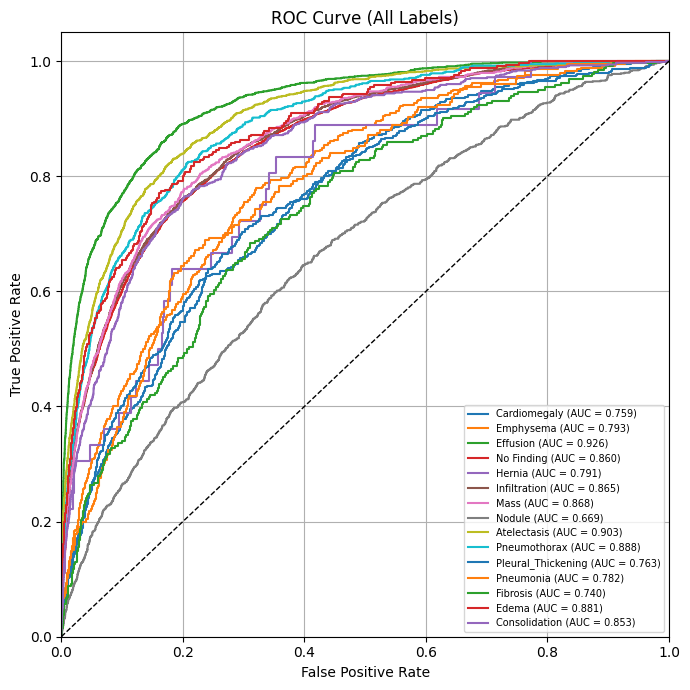

In [ ]:
plt.figure(figsize=(7, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    auc_val = roc_auc_score(y_true[:, i], y_score[:, i])
    plt.plot(fpr, tpr, linewidth=1.5,
             label=f"{disease_names[i]} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Labels)")
plt.legend(loc="lower right", fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()